<a href="https://colab.research.google.com/github/Ram-Pathuri/Ads-Click-Through-Rate-/blob/main/student_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
train_data = pd.read_csv("/content/train.csv")

In [ ]:
train_data.head(5)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [ ]:
test_data = pd.read_csv("/content/test.csv")

In [ ]:
test_data.columns

Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='object')

In [ ]:
train_data.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [ ]:
train_data['health_condition'].value_counts()/len(train_data)*100

,count
health_condition,
at-risk,85.808452
unhealthy,8.379341
fit,5.812207


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197068 entries, 0 to 197067
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       197068 non-null  int64  
 1   health_condition         197068 non-null  object 
 2   sleep_duration           175320 non-null  float64
 3   heart_rate               194812 non-null  float64
 4   bmi                      193062 non-null  float64
 5   calorie_expenditure      181909 non-null  float64
 6   step_count               193160 non-null  float64
 7   exercise_duration        195109 non-null  float64
 8   water_intake             184609 non-null  float64
 9   diet_type                195090 non-null  object 
 10  stress_level             173434 non-null  object 
 11  sleep_quality            180442 non-null  object 
 12  physical_activity_level  186424 non-null  object 
 13  smoking_alcohol          188754 non-null  object 
 14  gend

In [ ]:
obj_cols = train_data.select_dtypes(include=['object'])
num_cols = train_data.select_dtypes(include=['int64', 'float64'])


In [ ]:
for i in obj_cols:
  print(train_data[i].value_counts()/len(train_data)*100)
  print("===============================================================")

health_condition
at-risk      85.808452
unhealthy     8.379341
fit           5.812207
Name: count, dtype: float64
diet_type
veg         33.410295
balanced    33.054073
non-veg     32.531918
Name: count, dtype: float64
stress_level
medium    37.960501
high      25.737309
low       24.309375
Name: count, dtype: float64
sleep_quality
average    31.059330
poor       30.577263
good       29.926726
Name: count, dtype: float64
physical_activity_level
sedentary    31.925021
moderate     31.766700
active       30.907098
Name: count, dtype: float64
smoking_alcohol
yes           32.337569
no            31.845353
occasional    31.598230
Name: count, dtype: float64
gender
male      34.427710
female    32.386283
other     30.061705
Name: count, dtype: float64


is Null values are present: YES

In [ ]:
# @title
k = train_data.isnull().sum()/len(train_data)*100
# 0% < Missing <= 5%
bucket_0_5 = k[(k > 0) & (k <= 5)]

# 5% < Missing <= 10%
bucket_5_10 = k[(k > 5) & (k <= 10)]

# Missing > 10%
bucket_above_10 = k[k > 10]

print("0-5% Missing:")
print(bucket_0_5)

print("\n5-10% Missing:")
print(bucket_5_10)

print("\nAbove 10% Missing:")
print(bucket_above_10)

0-5% Missing:
heart_rate           1.144783
bmi                  2.032801
step_count           1.983072
exercise_duration    0.994073
diet_type            1.003714
smoking_alcohol      4.218848
gender               3.124302
dtype: float64

5-10% Missing:
calorie_expenditure        7.692269
water_intake               6.322183
sleep_quality              8.436682
physical_activity_level    5.401181
dtype: float64

Above 10% Missing:
sleep_duration    11.035785
stress_level      11.992815
dtype: float64


<Axes: >

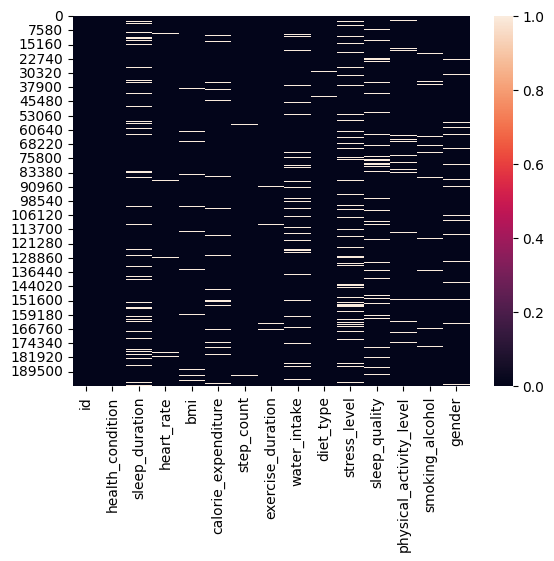

In [ ]:
# @title
sns.heatmap(train_data.isnull())

In [ ]:
# @title
import plotly.express as px

missing = (
    train_data.isnull()
    .mean()
    .mul(100)
    .reset_index()
)

missing.columns = ["Column", "Missing %"]

fig = px.bar(
    missing.sort_values("Missing %", ascending=False),
    x="Column",
    y="Missing %",
    text="Missing %",
    title="Percentage of Missing Values by Column"
)

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
fig.update_layout(
    xaxis_tickangle=-45,
    yaxis_title="Missing (%)"
)

fig.show()

No duplicate rows

In [ ]:
# @title

train_data.duplicated().sum()
train_data[train_data.duplicated()]

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


Data is imbalanced

In [ ]:
# @title
import plotly.express as px

fig = px.histogram(
    train_data,
    x="health_condition",
    title="Count of Health Condition",
    text_auto=True
)

fig.update_layout(
    xaxis_title="Health Condition",
    yaxis_title="Count",
    bargap=0.2
)

fig.show()

ValueError: Boolean array expected for the condition, not int64

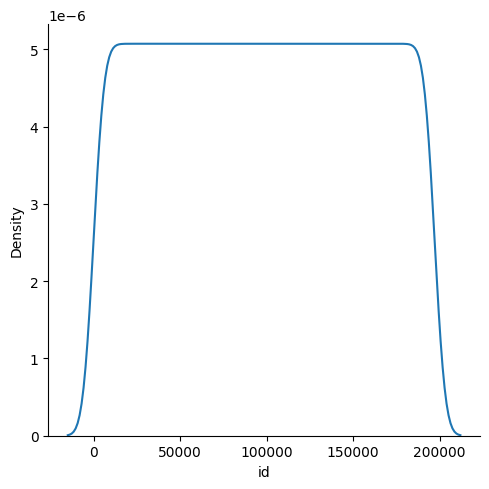

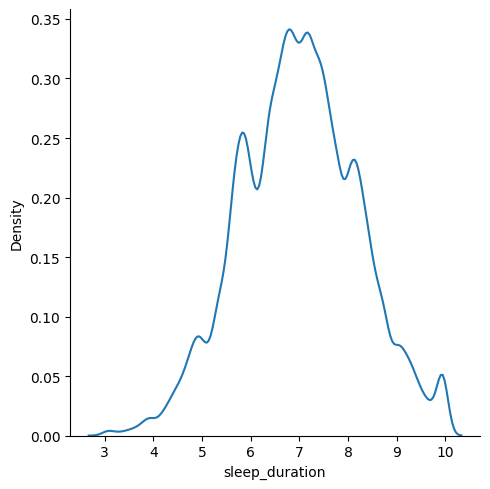

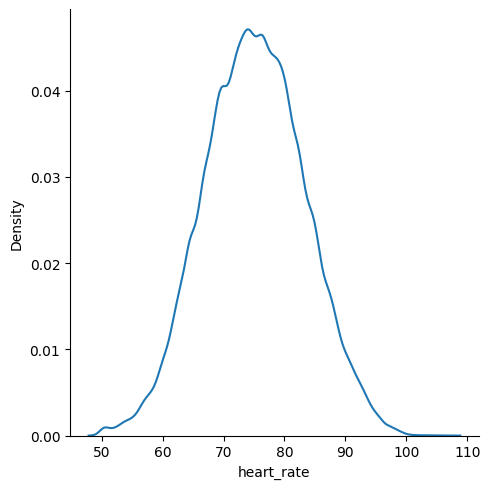

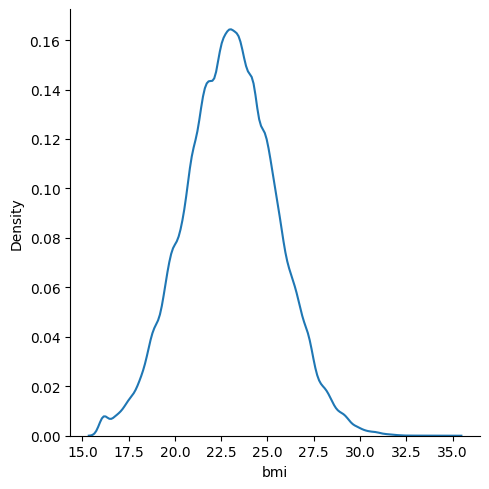

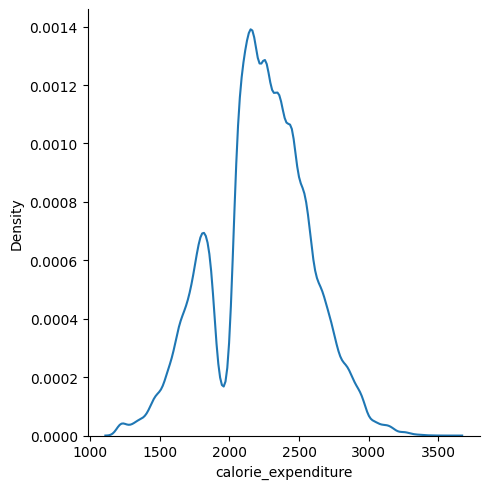

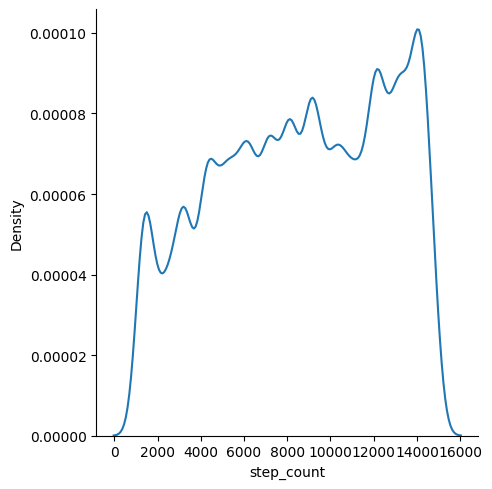

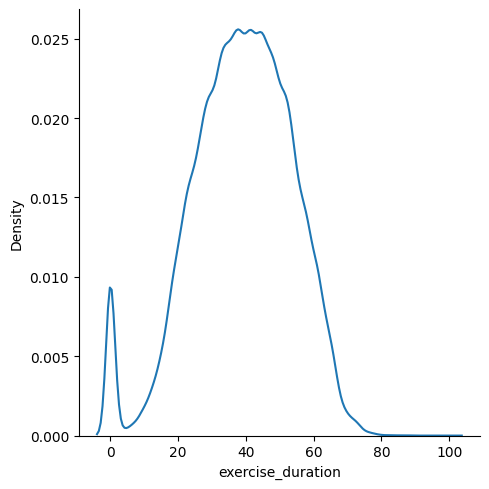

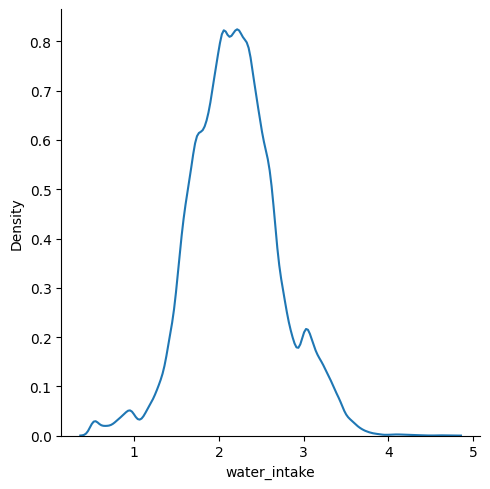

In [ ]:
# @title
for i in num_cols:sns.displot(train_data[i],kind='kde')

In [ ]:
# @title
skewness = num_cols.skew()

def skew_category(x):
    if abs(x) < 0.5:
        return "Approximately Symmetric"
    elif abs(x) < 1:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"

skew_df = pd.DataFrame({
    "Skewness": skewness,
    "Category": skewness.apply(skew_category)
})

print(skew_df.sort_values(by="Skewness", key=abs, ascending=False))

                         Skewness                 Category
exercise_duration   -3.726464e-01  Approximately Symmetric
calorie_expenditure -1.842096e-01  Approximately Symmetric
step_count          -1.836925e-01  Approximately Symmetric
water_intake         1.127782e-01  Approximately Symmetric
bmi                  1.612280e-02  Approximately Symmetric
sleep_duration      -1.213137e-02  Approximately Symmetric
heart_rate           3.879216e-03  Approximately Symmetric
id                  -1.763968e-18  Approximately Symmetric


In [ ]:
# @title
outlier_summary = []

for col in num_cols.columns:
    Q1 = num_cols[col].quantile(0.25)
    Q3 = num_cols[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((num_cols[col] < lower) | (num_cols[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Outliers": outliers,
        "Outlier %": round(outliers / len(num_cols) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df.sort_values("Outlier %", ascending=False))

                Column  Outliers  Outlier %
4  calorie_expenditure      3614       1.83
7         water_intake      3449       1.75
3                  bmi      1522       0.77
2           heart_rate       786       0.40
1       sleep_duration       547       0.28
6    exercise_duration        33       0.02
0                   id         0       0.00
5           step_count         0       0.00


<Axes: >

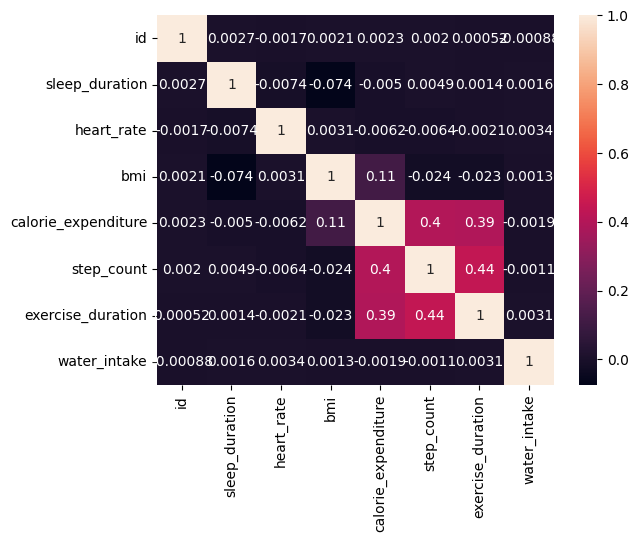

In [ ]:
sns.heatmap(train_data.corr(numeric_only=True),annot=True)

<Axes: xlabel='exercise_duration', ylabel='calorie_expenditure'>

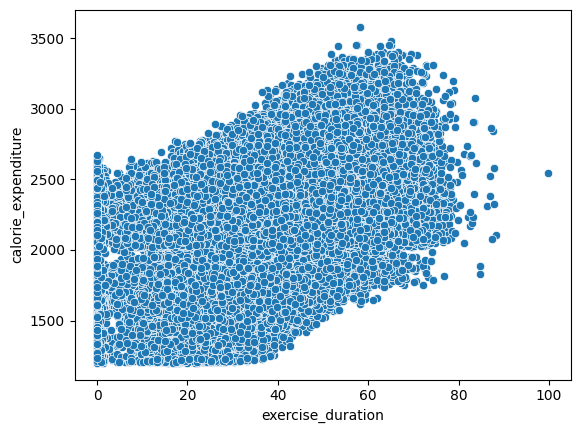

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=train_data, x='exercise_duration', y='calorie_expenditure')


In [ ]:
obj_cols.columns

Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

<Axes: xlabel='calorie_expenditure', ylabel='health_condition'>

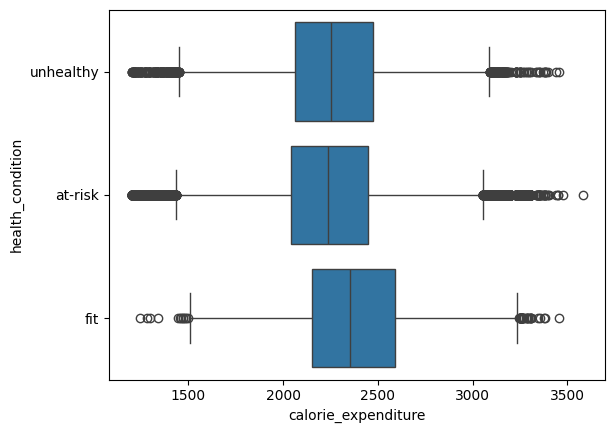

In [ ]:
# @title
sns.boxplot(data=train_data,x='calorie_expenditure',y='health_condition')

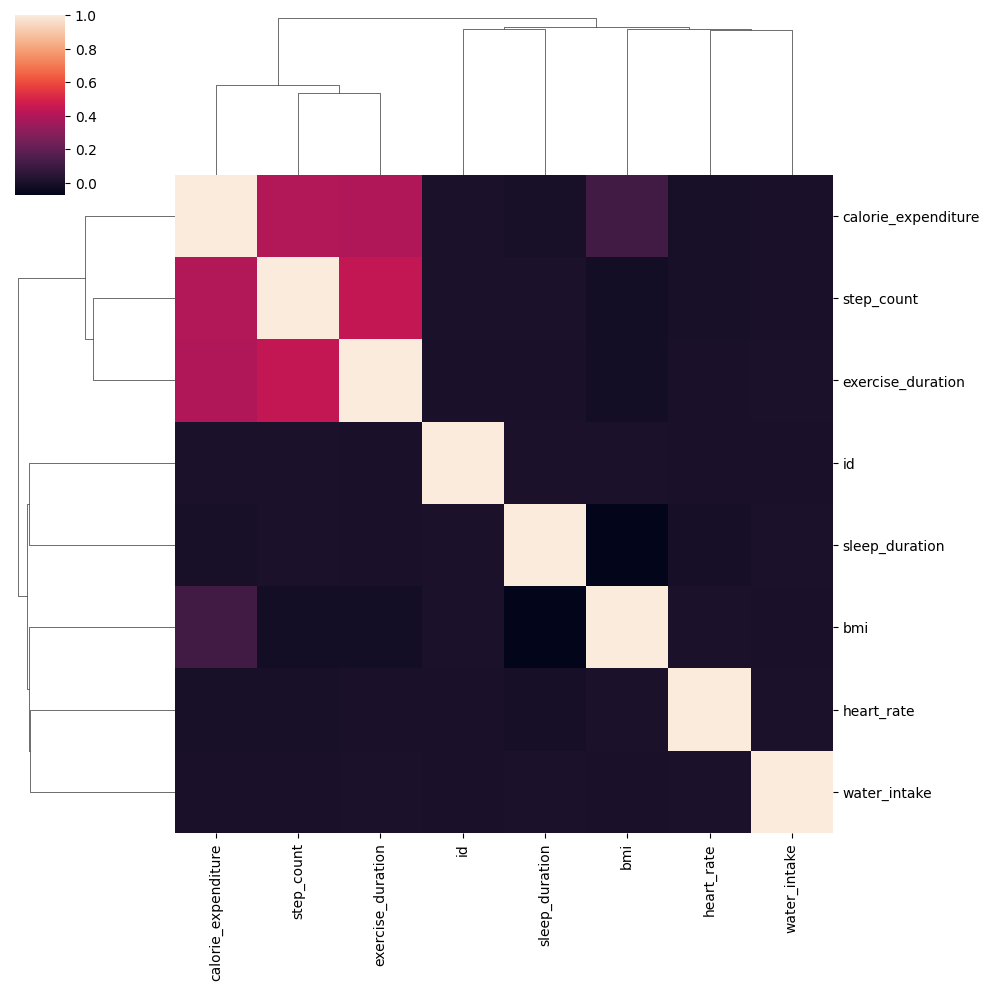

In [ ]:
sns.clustermap(train_data.corr(numeric_only=True))